In [65]:
!pip install torchvision


In [66]:
import os
import kagglehub
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, confusion_matrix

from PIL import Image
from torchvision import transforms
from sklearn.metrics import precision_score, recall_score, f1_score


In [67]:
#Download the dataset
path = kagglehub.dataset_download("swaroopkml/cifar10-pngs-in-folders")

print("Dataset downloaded to:", path)
print("Contents at root:", os.listdir(path))

#"cifar10" path
data_root = os.path.join(path, "cifar10", "cifar10")
print("cifar10/cifar10 contents:", os.listdir(data_root))

#train and test path
train_root = os.path.join(data_root, "train")
test_root  = os.path.join(data_root, "test")

print("Train path:", train_root)
print("Test path:", test_root)

Dataset downloaded to: /Users/khaledehab/.cache/kagglehub/datasets/swaroopkml/cifar10-pngs-in-folders/versions/1
Contents at root: ['cifar10']
cifar10/cifar10 contents: ['test', 'train']
Train path: /Users/khaledehab/.cache/kagglehub/datasets/swaroopkml/cifar10-pngs-in-folders/versions/1/cifar10/cifar10/train
Test path: /Users/khaledehab/.cache/kagglehub/datasets/swaroopkml/cifar10-pngs-in-folders/versions/1/cifar10/cifar10/test


In [68]:
class Cifar10PngDataset(Dataset):
    def __init__(self, root, transform=None):

        self.root = root
        self.transform = transform
        self.samples = []
        self.class_map = {}  

        #each folder is a class label
        class_names = sorted(
            [d for d in os.listdir(self.root) if os.path.isdir(os.path.join(self.root, d))]
        )

        for class_idx, class_name in enumerate(class_names):
            class_dir = os.path.join(self.root, class_name)
            self.class_map[class_name] = class_idx

            #load all images
            for fname in os.listdir(class_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    img_path = os.path.join(class_dir, fname)
                    self.samples.append((img_path, class_idx))

        print(f"Loaded {len(self.samples)} images and {len(self.class_map)} classes from {self.root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        #convert to rgb
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


In [69]:

#preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),   
        std=(0.2470, 0.2435, 0.2616)     
    )
])


transforms.ColorJitter(
    brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
)


ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))

In [70]:

#split dataset


full_train_dataset = Cifar10PngDataset(train_root, transform)
test_dataset       = Cifar10PngDataset(test_root,  transform)

train_size = int(0.8 * len(full_train_dataset))
val_size   = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

#get number of classes
num_classes = len(full_train_dataset.class_map)
print("Number of classes:", num_classes)


Loaded 50000 images and 10 classes from /Users/khaledehab/.cache/kagglehub/datasets/swaroopkml/cifar10-pngs-in-folders/versions/1/cifar10/cifar10/train
Loaded 10000 images and 10 classes from /Users/khaledehab/.cache/kagglehub/datasets/swaroopkml/cifar10-pngs-in-folders/versions/1/cifar10/cifar10/test
Train samples: 40000
Validation samples: 10000
Test samples: 10000
Number of classes: 10


In [71]:
#metrics

def compute_metrics(outputs, labels):
    preds = outputs.argmax(dim=1).cpu()
    labels = labels.cpu()

    acc = (preds == labels).float().mean().item()
    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall    = recall_score(labels, preds, average="macro", zero_division=0)
    f1        = f1_score(labels, preds, average="macro", zero_division=0)

    return acc, precision, recall, f1


In [72]:

#train function

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def train_model(model, train_loader, val_loader, epochs, lr, run_name):
    writer = SummaryWriter(log_dir=f"runs/{run_name}")
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    global_step = 0

    history = {
        "train_loss": [],
        "train_acc":  [],
        "train_f1":   [],
        "val_loss":   [],
        "val_acc":    [],
        "val_f1":     [],
        "val_roc_auc": [],
        "val_confusion_matrix": []   
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_acc  = 0.0
        train_f1   = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            
            acc, _, _, f1 = compute_metrics(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc  += acc
            train_f1   += f1

            writer.add_scalar("Train/Batch_Loss", loss.item(), global_step)
            writer.add_scalar("Train/Batch_Acc",  acc,          global_step)
            global_step += 1

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc  = train_acc  / len(train_loader)
        avg_train_f1   = train_f1   / len(train_loader)

        
        model.eval()
        val_loss = 0.0
        val_acc  = 0.0
        val_f1   = 0.0

        all_labels = []
        all_probs  = []
        all_preds  = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                acc, _, _, f1 = compute_metrics(outputs, labels)

                val_loss += loss.item()
                val_acc  += acc
                val_f1   += f1

                
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                preds = outputs.argmax(dim=1).cpu().numpy()

                all_probs.append(probs)
                all_preds.append(preds)
                all_labels.append(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc  = val_acc  / len(val_loader)
        avg_val_f1   = val_f1   / len(val_loader)

        y_true  = np.concatenate(all_labels, axis=0)
        y_proba = np.concatenate(all_probs,  axis=0)
        y_pred  = np.concatenate(all_preds,  axis=0)

       
        val_roc_auc = roc_auc_score(y_true, y_proba, multi_class="ovr")

        num_classes = y_proba.shape[1]
        cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

        #save to history
        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(avg_train_acc)
        history["train_f1"].append(avg_train_f1)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(avg_val_acc)
        history["val_f1"].append(avg_val_f1)
        history["val_roc_auc"].append(val_roc_auc)
        history["val_confusion_matrix"].append(cm)

        #print each epoch
        writer.add_scalar("Train/Epoch_Loss",   avg_train_loss, epoch)
        writer.add_scalar("Train/Epoch_Acc",    avg_train_acc,  epoch)
        writer.add_scalar("Train/Epoch_F1",     avg_train_f1,   epoch)

        writer.add_scalar("Val/Epoch_Loss",     avg_val_loss,   epoch)
        writer.add_scalar("Val/Epoch_Acc",      avg_val_acc,    epoch)
        writer.add_scalar("Val/Epoch_F1",       avg_val_f1,     epoch)
        writer.add_scalar("Val/Epoch_ROC_AUC",  val_roc_auc,    epoch)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f} | "
            f"Train Acc: {avg_train_acc:.4f}, Val Acc: {avg_val_acc:.4f} | "
            f"Val F1: {avg_val_f1:.4f}, Val ROC-AUC: {val_roc_auc:.4f}"
        )

    writer.close()
    return model, history


Using device: cpu


In [73]:


class SparseHopfieldLayer(nn.Module):
  
    def __init__(self, dim, num_patterns=512, top_k=32):
        super().__init__()
        self.dim = dim
        self.num_patterns = num_patterns
        self.top_k = top_k

       
        self.patterns = nn.Parameter(torch.randn(num_patterns, dim) * 0.1)

    def forward(self, x):
        """
        x: (batch, dim)
        return: (batch, dim)
        """
        scores = x @ self.patterns.t()
        scores = scores / math.sqrt(self.dim)

        k = min(self.top_k, self.num_patterns)
        topk_vals, topk_idx = scores.topk(k, dim=-1)

        sparse_scores = torch.full_like(scores, float("-inf"))
        sparse_scores.scatter_(dim=-1, index=topk_idx, src=topk_vals)

        attn = torch.softmax(sparse_scores, dim=-1)  

        hopped = attn @ self.patterns

        return x + hopped


In [74]:

class SparseHopfieldNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

   
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),      

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),      

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)       
        )

        in_features = 128 * 4 * 4   
        hop_dim = 256               

        self.to_hopfield = nn.Sequential(
            nn.Linear(in_features, hop_dim),
            nn.ReLU()
        )

        self.hopfield = SparseHopfieldLayer(
            dim=hop_dim,
            num_patterns=512,
            top_k=32
        )

        self.classifier = nn.Linear(hop_dim, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        x = self.to_hopfield(x)
        x = self.hopfield(x)
        x = self.classifier(x)
        return x


In [75]:


sparse_model = SparseHopfieldNet(num_classes=num_classes)

trained_sparse = train_model(
    sparse_model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="sparse_hopfield_main"
)


Epoch 1/10 | Train Loss: 1.4198, Val Loss: 1.1062 | Train Acc: 0.4860, Val Acc: 0.6071 | Val F1: 0.5830, Val ROC-AUC: 0.9338
Epoch 2/10 | Train Loss: 0.9631, Val Loss: 0.8936 | Train Acc: 0.6583, Val Acc: 0.6897 | Val F1: 0.6719, Val ROC-AUC: 0.9538
Epoch 3/10 | Train Loss: 0.7648, Val Loss: 0.8165 | Train Acc: 0.7312, Val Acc: 0.7110 | Val F1: 0.6820, Val ROC-AUC: 0.9613
Epoch 4/10 | Train Loss: 0.6292, Val Loss: 0.7633 | Train Acc: 0.7763, Val Acc: 0.7321 | Val F1: 0.7147, Val ROC-AUC: 0.9655
Epoch 5/10 | Train Loss: 0.5159, Val Loss: 0.7724 | Train Acc: 0.8188, Val Acc: 0.7408 | Val F1: 0.7196, Val ROC-AUC: 0.9662
Epoch 6/10 | Train Loss: 0.4192, Val Loss: 0.7965 | Train Acc: 0.8521, Val Acc: 0.7417 | Val F1: 0.7223, Val ROC-AUC: 0.9668
Epoch 7/10 | Train Loss: 0.3314, Val Loss: 0.8790 | Train Acc: 0.8815, Val Acc: 0.7401 | Val F1: 0.7217, Val ROC-AUC: 0.9653
Epoch 8/10 | Train Loss: 0.2521, Val Loss: 0.9070 | Train Acc: 0.9106, Val Acc: 0.7437 | Val F1: 0.7246, Val ROC-AUC: 0.9656


In [76]:
sparse_A = SparseHopfieldNet(num_classes=num_classes)
sparse_A.hopfield.num_patterns = 256
sparse_A.hopfield.top_k = 16

trained_sparse_A = train_model(
    sparse_A,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0005,
    run_name="sparse_hopfield_A_small"
)


Epoch 1/10 | Train Loss: 1.4804, Val Loss: 1.2177 | Train Acc: 0.4620, Val Acc: 0.5707 | Val F1: 0.5481, Val ROC-AUC: 0.9196
Epoch 2/10 | Train Loss: 1.0727, Val Loss: 0.9634 | Train Acc: 0.6193, Val Acc: 0.6658 | Val F1: 0.6415, Val ROC-AUC: 0.9458
Epoch 3/10 | Train Loss: 0.8835, Val Loss: 0.8707 | Train Acc: 0.6890, Val Acc: 0.6894 | Val F1: 0.6667, Val ROC-AUC: 0.9554
Epoch 4/10 | Train Loss: 0.7516, Val Loss: 0.8258 | Train Acc: 0.7368, Val Acc: 0.7153 | Val F1: 0.6937, Val ROC-AUC: 0.9592
Epoch 5/10 | Train Loss: 0.6505, Val Loss: 0.7805 | Train Acc: 0.7735, Val Acc: 0.7335 | Val F1: 0.7141, Val ROC-AUC: 0.9635
Epoch 6/10 | Train Loss: 0.5565, Val Loss: 0.7689 | Train Acc: 0.8060, Val Acc: 0.7366 | Val F1: 0.7171, Val ROC-AUC: 0.9657
Epoch 7/10 | Train Loss: 0.4734, Val Loss: 0.7778 | Train Acc: 0.8344, Val Acc: 0.7449 | Val F1: 0.7278, Val ROC-AUC: 0.9660
Epoch 8/10 | Train Loss: 0.3895, Val Loss: 0.8470 | Train Acc: 0.8639, Val Acc: 0.7362 | Val F1: 0.7146, Val ROC-AUC: 0.9656


In [77]:
sparse_B = SparseHopfieldNet(num_classes=num_classes)
sparse_B.hopfield.num_patterns = 1024
sparse_B.hopfield.top_k = 64

trained_sparse_B = train_model(
    sparse_B,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="sparse_hopfield_B_large"
)


Epoch 1/10 | Train Loss: 1.3839, Val Loss: 1.0331 | Train Acc: 0.5013, Val Acc: 0.6354 | Val F1: 0.6064, Val ROC-AUC: 0.9369
Epoch 2/10 | Train Loss: 0.9487, Val Loss: 0.8913 | Train Acc: 0.6635, Val Acc: 0.6894 | Val F1: 0.6647, Val ROC-AUC: 0.9540
Epoch 3/10 | Train Loss: 0.7607, Val Loss: 0.8281 | Train Acc: 0.7344, Val Acc: 0.7151 | Val F1: 0.6981, Val ROC-AUC: 0.9598
Epoch 4/10 | Train Loss: 0.6222, Val Loss: 0.7667 | Train Acc: 0.7831, Val Acc: 0.7412 | Val F1: 0.7215, Val ROC-AUC: 0.9653
Epoch 5/10 | Train Loss: 0.5153, Val Loss: 0.7442 | Train Acc: 0.8187, Val Acc: 0.7463 | Val F1: 0.7303, Val ROC-AUC: 0.9664
Epoch 6/10 | Train Loss: 0.4030, Val Loss: 0.8303 | Train Acc: 0.8593, Val Acc: 0.7399 | Val F1: 0.7164, Val ROC-AUC: 0.9660
Epoch 7/10 | Train Loss: 0.3084, Val Loss: 0.8596 | Train Acc: 0.8915, Val Acc: 0.7419 | Val F1: 0.7199, Val ROC-AUC: 0.9658
Epoch 8/10 | Train Loss: 0.2321, Val Loss: 0.9345 | Train Acc: 0.9174, Val Acc: 0.7471 | Val F1: 0.7264, Val ROC-AUC: 0.9658


In [78]:
sparse_C = SparseHopfieldNet(num_classes=num_classes)
sparse_C.hopfield.top_k = 4    

trained_sparse_C = train_model(
    sparse_C,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="sparse_hopfield_C_extreme_sparse"
)


Epoch 1/10 | Train Loss: 1.3886, Val Loss: 1.0862 | Train Acc: 0.4933, Val Acc: 0.6087 | Val F1: 0.5822, Val ROC-AUC: 0.9328
Epoch 2/10 | Train Loss: 0.9584, Val Loss: 0.9158 | Train Acc: 0.6615, Val Acc: 0.6762 | Val F1: 0.6530, Val ROC-AUC: 0.9518
Epoch 3/10 | Train Loss: 0.7728, Val Loss: 0.8379 | Train Acc: 0.7270, Val Acc: 0.7075 | Val F1: 0.6765, Val ROC-AUC: 0.9592
Epoch 4/10 | Train Loss: 0.6377, Val Loss: 0.8077 | Train Acc: 0.7738, Val Acc: 0.7172 | Val F1: 0.6990, Val ROC-AUC: 0.9631
Epoch 5/10 | Train Loss: 0.5255, Val Loss: 0.7528 | Train Acc: 0.8135, Val Acc: 0.7441 | Val F1: 0.7243, Val ROC-AUC: 0.9670
Epoch 6/10 | Train Loss: 0.4258, Val Loss: 0.8032 | Train Acc: 0.8483, Val Acc: 0.7492 | Val F1: 0.7248, Val ROC-AUC: 0.9665
Epoch 7/10 | Train Loss: 0.3421, Val Loss: 0.8051 | Train Acc: 0.8786, Val Acc: 0.7519 | Val F1: 0.7290, Val ROC-AUC: 0.9666
Epoch 8/10 | Train Loss: 0.2578, Val Loss: 0.9712 | Train Acc: 0.9084, Val Acc: 0.7416 | Val F1: 0.7219, Val ROC-AUC: 0.9660


In [79]:

sparse_best = SparseHopfieldNet(num_classes=num_classes)

in_features = 128 * 4 * 4 


sparse_best.to_hopfield = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU()
)

sparse_best.hopfield = SparseHopfieldLayer(
    dim=512,
    num_patterns=1024,  
    top_k=32             
)

sparse_best.classifier = nn.Linear(512, num_classes)

trained_sparse_best, hist_sparse = train_model(
    sparse_best,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0007,  
    run_name="sparse_hopfield_best"
)


Epoch 1/10 | Train Loss: 1.3943, Val Loss: 1.0439 | Train Acc: 0.4958, Val Acc: 0.6298 | Val F1: 0.6013, Val ROC-AUC: 0.9357
Epoch 2/10 | Train Loss: 0.9439, Val Loss: 0.9710 | Train Acc: 0.6657, Val Acc: 0.6593 | Val F1: 0.6323, Val ROC-AUC: 0.9507
Epoch 3/10 | Train Loss: 0.7442, Val Loss: 0.7839 | Train Acc: 0.7383, Val Acc: 0.7281 | Val F1: 0.7079, Val ROC-AUC: 0.9637
Epoch 4/10 | Train Loss: 0.6015, Val Loss: 0.7349 | Train Acc: 0.7887, Val Acc: 0.7486 | Val F1: 0.7291, Val ROC-AUC: 0.9679
Epoch 5/10 | Train Loss: 0.4865, Val Loss: 0.7141 | Train Acc: 0.8279, Val Acc: 0.7541 | Val F1: 0.7357, Val ROC-AUC: 0.9697
Epoch 6/10 | Train Loss: 0.3663, Val Loss: 0.8111 | Train Acc: 0.8702, Val Acc: 0.7474 | Val F1: 0.7203, Val ROC-AUC: 0.9680
Epoch 7/10 | Train Loss: 0.2643, Val Loss: 0.8734 | Train Acc: 0.9063, Val Acc: 0.7492 | Val F1: 0.7328, Val ROC-AUC: 0.9680
Epoch 8/10 | Train Loss: 0.1814, Val Loss: 0.9284 | Train Acc: 0.9369, Val Acc: 0.7485 | Val F1: 0.7289, Val ROC-AUC: 0.9663


In [80]:
cm_sparse = hist_sparse["val_confusion_matrix"][-1]
print("Sparse Hopfield Confusion Matrix:\n", cm_sparse)


Sparse Hopfield Confusion Matrix:
 [[813  12  52  23  18   8   5  15  55  41]
 [ 17 826   6   4   3   1  10   2  17 111]
 [ 42   3 705  68  51  34  43  26  13  16]
 [ 14   7  76 596  35 138  37  25   7  17]
 [ 21   4  94  81 678  25  21  62   8   5]
 [  6   0  71 200  46 586  14  40   3  10]
 [  4   4  53  72  39  15 771   9   4  11]
 [  6   5  43  68  46  31   8 799   4  10]
 [ 43  31  12   4   7   2   5   2 865  49]
 [ 20  47   9  23   2   2   4   8  12 884]]


In [81]:
class ModernHopfieldLayer(nn.Module):
  
  
    def __init__(self, dim, num_patterns=512, beta=1.0):
        super().__init__()
        self.dim = dim
        self.num_patterns = num_patterns
        self.beta = beta  

        
        self.patterns = nn.Parameter(torch.randn(num_patterns, dim) * 0.1)

    def forward(self, x):
       
        
        scores = x @ self.patterns.t()
        scores = scores / math.sqrt(self.dim)   
        scores = self.beta * scores             

        attn = torch.softmax(scores, dim=-1)    

        hopped = attn @ self.patterns          

        return x + hopped

In [82]:
class ModernHopfieldNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),     

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),      

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)       
        )

        in_features = 128 * 4 * 4
        hop_dim = 256

        self.to_hopfield = nn.Sequential(
            nn.Linear(in_features, hop_dim),
            nn.ReLU()
        )

        self.hopfield = ModernHopfieldLayer(
            dim=hop_dim,
            num_patterns=512,
            beta=1.0
        )

        self.classifier = nn.Linear(hop_dim, num_classes)

    def forward(self, x):
        # x: [B, 3, 32, 32]
        x = self.conv(x)                 
        x = x.reshape(x.size(0), -1)   
        x = self.to_hopfield(x)          
        x = self.hopfield(x)             
        x = self.classifier(x)           
        return x

In [83]:
modern_model = ModernHopfieldNet(num_classes=num_classes)

trained_modern = train_model(
    modern_model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="modern_hopfield_main"
)


Epoch 1/10 | Train Loss: 1.3894, Val Loss: 1.0555 | Train Acc: 0.4969, Val Acc: 0.6284 | Val F1: 0.6024, Val ROC-AUC: 0.9354
Epoch 2/10 | Train Loss: 0.9512, Val Loss: 0.8856 | Train Acc: 0.6651, Val Acc: 0.6892 | Val F1: 0.6652, Val ROC-AUC: 0.9557
Epoch 3/10 | Train Loss: 0.7568, Val Loss: 0.8157 | Train Acc: 0.7352, Val Acc: 0.7189 | Val F1: 0.7052, Val ROC-AUC: 0.9621
Epoch 4/10 | Train Loss: 0.6250, Val Loss: 0.7919 | Train Acc: 0.7830, Val Acc: 0.7235 | Val F1: 0.6958, Val ROC-AUC: 0.9669
Epoch 5/10 | Train Loss: 0.5042, Val Loss: 0.7796 | Train Acc: 0.8228, Val Acc: 0.7466 | Val F1: 0.7269, Val ROC-AUC: 0.9667
Epoch 6/10 | Train Loss: 0.4044, Val Loss: 0.8045 | Train Acc: 0.8579, Val Acc: 0.7419 | Val F1: 0.7194, Val ROC-AUC: 0.9660
Epoch 7/10 | Train Loss: 0.3092, Val Loss: 0.8760 | Train Acc: 0.8906, Val Acc: 0.7472 | Val F1: 0.7272, Val ROC-AUC: 0.9673
Epoch 8/10 | Train Loss: 0.2371, Val Loss: 0.9019 | Train Acc: 0.9146, Val Acc: 0.7500 | Val F1: 0.7308, Val ROC-AUC: 0.9681


In [84]:
modern_v2 = ModernHopfieldNet(num_classes=num_classes)

modern_v2.hopfield = ModernHopfieldLayer(
    dim=256,
    num_patterns=512,
    beta=2.0       
)

trained_modern_v2 = train_model(
    modern_v2,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="modern_v2_beta_2_0"
)


Epoch 1/10 | Train Loss: 1.4259, Val Loss: 1.1483 | Train Acc: 0.4831, Val Acc: 0.5857 | Val F1: 0.5639, Val ROC-AUC: 0.9294
Epoch 2/10 | Train Loss: 0.9702, Val Loss: 0.8660 | Train Acc: 0.6575, Val Acc: 0.7018 | Val F1: 0.6805, Val ROC-AUC: 0.9550
Epoch 3/10 | Train Loss: 0.7733, Val Loss: 0.8095 | Train Acc: 0.7278, Val Acc: 0.7166 | Val F1: 0.6955, Val ROC-AUC: 0.9627
Epoch 4/10 | Train Loss: 0.6309, Val Loss: 0.7338 | Train Acc: 0.7783, Val Acc: 0.7458 | Val F1: 0.7310, Val ROC-AUC: 0.9672
Epoch 5/10 | Train Loss: 0.5153, Val Loss: 0.7472 | Train Acc: 0.8184, Val Acc: 0.7461 | Val F1: 0.7255, Val ROC-AUC: 0.9666
Epoch 6/10 | Train Loss: 0.4140, Val Loss: 0.7888 | Train Acc: 0.8548, Val Acc: 0.7549 | Val F1: 0.7361, Val ROC-AUC: 0.9685
Epoch 7/10 | Train Loss: 0.3319, Val Loss: 0.8415 | Train Acc: 0.8824, Val Acc: 0.7427 | Val F1: 0.7252, Val ROC-AUC: 0.9658
Epoch 8/10 | Train Loss: 0.2520, Val Loss: 0.9198 | Train Acc: 0.9104, Val Acc: 0.7417 | Val F1: 0.7227, Val ROC-AUC: 0.9655


In [85]:
modern_v3 = ModernHopfieldNet(num_classes=num_classes)

modern_v3.hopfield = ModernHopfieldLayer(
    dim=256,
    num_patterns=1024,   
    beta=1.0
)

trained_modern_v3 = train_model(
    modern_v3,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="modern_v3_1024_patterns"
)


Epoch 1/10 | Train Loss: 1.4023, Val Loss: 1.0799 | Train Acc: 0.4910, Val Acc: 0.6195 | Val F1: 0.5918, Val ROC-AUC: 0.9340
Epoch 2/10 | Train Loss: 0.9530, Val Loss: 0.8720 | Train Acc: 0.6634, Val Acc: 0.6958 | Val F1: 0.6735, Val ROC-AUC: 0.9539
Epoch 3/10 | Train Loss: 0.7695, Val Loss: 0.8018 | Train Acc: 0.7304, Val Acc: 0.7185 | Val F1: 0.6971, Val ROC-AUC: 0.9617
Epoch 4/10 | Train Loss: 0.6365, Val Loss: 0.7597 | Train Acc: 0.7781, Val Acc: 0.7388 | Val F1: 0.7199, Val ROC-AUC: 0.9659
Epoch 5/10 | Train Loss: 0.5286, Val Loss: 0.8231 | Train Acc: 0.8146, Val Acc: 0.7355 | Val F1: 0.7160, Val ROC-AUC: 0.9643
Epoch 6/10 | Train Loss: 0.4269, Val Loss: 0.7964 | Train Acc: 0.8483, Val Acc: 0.7504 | Val F1: 0.7282, Val ROC-AUC: 0.9675
Epoch 7/10 | Train Loss: 0.3300, Val Loss: 0.8249 | Train Acc: 0.8833, Val Acc: 0.7506 | Val F1: 0.7309, Val ROC-AUC: 0.9666
Epoch 8/10 | Train Loss: 0.2483, Val Loss: 0.9967 | Train Acc: 0.9113, Val Acc: 0.7241 | Val F1: 0.7030, Val ROC-AUC: 0.9627


In [86]:
modern_v4 = ModernHopfieldNet(num_classes=num_classes)

in_features = 128 * 4 * 4

modern_v4.to_hopfield = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU()
)

modern_v4.hopfield = ModernHopfieldLayer(
    dim=512,
    num_patterns=512,
    beta=1.0
)

modern_v4.classifier = nn.Linear(512, num_classes)

trained_modern_v4 = train_model(
    modern_v4,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0008,
    run_name="modern_v4_high_dim"
)


Epoch 1/10 | Train Loss: 1.3880, Val Loss: 1.0465 | Train Acc: 0.4972, Val Acc: 0.6228 | Val F1: 0.5994, Val ROC-AUC: 0.9367
Epoch 2/10 | Train Loss: 0.9347, Val Loss: 0.8477 | Train Acc: 0.6692, Val Acc: 0.6995 | Val F1: 0.6787, Val ROC-AUC: 0.9575
Epoch 3/10 | Train Loss: 0.7467, Val Loss: 0.7828 | Train Acc: 0.7365, Val Acc: 0.7241 | Val F1: 0.7050, Val ROC-AUC: 0.9636
Epoch 4/10 | Train Loss: 0.6076, Val Loss: 0.7341 | Train Acc: 0.7875, Val Acc: 0.7503 | Val F1: 0.7320, Val ROC-AUC: 0.9678
Epoch 5/10 | Train Loss: 0.4861, Val Loss: 0.7307 | Train Acc: 0.8291, Val Acc: 0.7610 | Val F1: 0.7427, Val ROC-AUC: 0.9690
Epoch 6/10 | Train Loss: 0.3772, Val Loss: 0.7875 | Train Acc: 0.8688, Val Acc: 0.7484 | Val F1: 0.7326, Val ROC-AUC: 0.9675
Epoch 7/10 | Train Loss: 0.2747, Val Loss: 0.8477 | Train Acc: 0.9027, Val Acc: 0.7575 | Val F1: 0.7397, Val ROC-AUC: 0.9684
Epoch 8/10 | Train Loss: 0.1905, Val Loss: 0.9774 | Train Acc: 0.9336, Val Acc: 0.7442 | Val F1: 0.7296, Val ROC-AUC: 0.9663


In [87]:
modern_best = ModernHopfieldNet(num_classes=num_classes)

in_features = 128 * 4 * 4

modern_best.to_hopfield = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU()
)

modern_best.hopfield = ModernHopfieldLayer(
    dim=512,
    num_patterns=768,  
    beta=1.5           
)

modern_best.classifier = nn.Linear(512, num_classes)

trained_modern_best, hist_modern = train_model(
    modern_best,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0007,
    run_name="modern_hopfield_best"
)


Epoch 1/10 | Train Loss: 1.4002, Val Loss: 1.1035 | Train Acc: 0.4911, Val Acc: 0.6111 | Val F1: 0.5867, Val ROC-AUC: 0.9320
Epoch 2/10 | Train Loss: 0.9829, Val Loss: 0.8851 | Train Acc: 0.6536, Val Acc: 0.6935 | Val F1: 0.6694, Val ROC-AUC: 0.9537
Epoch 3/10 | Train Loss: 0.7832, Val Loss: 0.7851 | Train Acc: 0.7252, Val Acc: 0.7276 | Val F1: 0.7079, Val ROC-AUC: 0.9632
Epoch 4/10 | Train Loss: 0.6483, Val Loss: 0.7905 | Train Acc: 0.7731, Val Acc: 0.7282 | Val F1: 0.7059, Val ROC-AUC: 0.9651
Epoch 5/10 | Train Loss: 0.5191, Val Loss: 0.7267 | Train Acc: 0.8181, Val Acc: 0.7493 | Val F1: 0.7324, Val ROC-AUC: 0.9694
Epoch 6/10 | Train Loss: 0.4092, Val Loss: 0.7404 | Train Acc: 0.8557, Val Acc: 0.7560 | Val F1: 0.7341, Val ROC-AUC: 0.9697
Epoch 7/10 | Train Loss: 0.3064, Val Loss: 0.8173 | Train Acc: 0.8920, Val Acc: 0.7471 | Val F1: 0.7213, Val ROC-AUC: 0.9677
Epoch 8/10 | Train Loss: 0.2142, Val Loss: 0.8938 | Train Acc: 0.9264, Val Acc: 0.7546 | Val F1: 0.7366, Val ROC-AUC: 0.9693


In [88]:
cm_modern = hist_modern["val_confusion_matrix"][-1]
print("Modern Hopfield Confusion Matrix:\n", cm_modern)

Modern Hopfield Confusion Matrix:
 [[844  27  27  13  11  21   3   7  51  38]
 [ 16 904   1   5   3   0   8   1   9  50]
 [ 72  10 606  61  84  65  56  27  13   7]
 [ 23  14  38 556  41 178  47  30   8  17]
 [ 29   3  60  57 711  36  27  70   4   2]
 [  3   2  29 147  50 659  27  51   1   7]
 [ 10  12  26  53  53  38 772   9   3   6]
 [ 15   5  16  44  42  58   4 820   3  13]
 [ 68  41   3   7   4   4   5   1 848  39]
 [ 26 100  10   6   2   8   6  11  15 827]]


In [89]:
class GaussianRBMNet(nn.Module):
   
    def __init__(self, num_classes, hidden_dim=512, eps=1e-6, learn_sigma=False):
        super().__init__()
        self.visible_dim = 3 * 32 * 32
        self.hidden_dim = hidden_dim
        self.eps = eps
        self.learn_sigma = learn_sigma

        self.W_vh = nn.Linear(self.visible_dim, self.hidden_dim)

        if learn_sigma:
            self.log_sigma = nn.Parameter(torch.zeros(self.visible_dim))
        else:
            self.register_buffer("sigma_fixed", torch.ones(self.visible_dim))

        self.classifier = nn.Linear(self.hidden_dim, num_classes)

    def forward(self, x):
        if x.dim() == 4:
            v = x.view(x.size(0), -1)   
        else:
            v = x

        if self.learn_sigma:
            sigma = torch.exp(self.log_sigma)      
            sigma = sigma.clamp(min=0.5, max=2.0)
        else:
            sigma = self.sigma_fixed               

        sigma2 = sigma * sigma + self.eps            
        v_scaled = v / sigma2                        

        h_pre = self.W_vh(v_scaled)                  
        h_prob = torch.sigmoid(h_pre)                

        logits = self.classifier(h_prob)             
        return logits


In [90]:
gaussian_rbm_model = GaussianRBMNet(
    num_classes=num_classes,
    hidden_dim=512,
    learn_sigma=False  
)

trained_gaussian_rbm = train_model(
    gaussian_rbm_model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="gaussian_rbm_main"
)


Epoch 1/10 | Train Loss: 1.7796, Val Loss: 1.6931 | Train Acc: 0.3799, Val Acc: 0.4120 | Val F1: 0.3822, Val ROC-AUC: 0.8248
Epoch 2/10 | Train Loss: 1.6547, Val Loss: 1.6436 | Train Acc: 0.4277, Val Acc: 0.4349 | Val F1: 0.4018, Val ROC-AUC: 0.8351
Epoch 3/10 | Train Loss: 1.5949, Val Loss: 1.6277 | Train Acc: 0.4536, Val Acc: 0.4388 | Val F1: 0.4094, Val ROC-AUC: 0.8400
Epoch 4/10 | Train Loss: 1.5450, Val Loss: 1.6014 | Train Acc: 0.4695, Val Acc: 0.4506 | Val F1: 0.4215, Val ROC-AUC: 0.8423
Epoch 5/10 | Train Loss: 1.5002, Val Loss: 1.5982 | Train Acc: 0.4860, Val Acc: 0.4568 | Val F1: 0.4242, Val ROC-AUC: 0.8443
Epoch 6/10 | Train Loss: 1.4589, Val Loss: 1.5814 | Train Acc: 0.5026, Val Acc: 0.4561 | Val F1: 0.4278, Val ROC-AUC: 0.8479
Epoch 7/10 | Train Loss: 1.4144, Val Loss: 1.5903 | Train Acc: 0.5196, Val Acc: 0.4575 | Val F1: 0.4274, Val ROC-AUC: 0.8482
Epoch 8/10 | Train Loss: 1.3752, Val Loss: 1.5792 | Train Acc: 0.5326, Val Acc: 0.4654 | Val F1: 0.4326, Val ROC-AUC: 0.8499


In [91]:
gaussian_rbm_v1 = GaussianRBMNet(
    num_classes=num_classes,
    hidden_dim=256,      
    learn_sigma=False
)

trained_gaussian_rbm_v1 = train_model(
    gaussian_rbm_v1,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="gaussian_rbm_v1_hidden256"
)


Epoch 1/10 | Train Loss: 1.7797, Val Loss: 1.6819 | Train Acc: 0.3816, Val Acc: 0.4176 | Val F1: 0.3827, Val ROC-AUC: 0.8268
Epoch 2/10 | Train Loss: 1.6637, Val Loss: 1.6479 | Train Acc: 0.4261, Val Acc: 0.4310 | Val F1: 0.4053, Val ROC-AUC: 0.8339
Epoch 3/10 | Train Loss: 1.6090, Val Loss: 1.6284 | Train Acc: 0.4474, Val Acc: 0.4348 | Val F1: 0.4028, Val ROC-AUC: 0.8372
Epoch 4/10 | Train Loss: 1.5647, Val Loss: 1.6126 | Train Acc: 0.4642, Val Acc: 0.4432 | Val F1: 0.4127, Val ROC-AUC: 0.8416
Epoch 5/10 | Train Loss: 1.5247, Val Loss: 1.5992 | Train Acc: 0.4783, Val Acc: 0.4543 | Val F1: 0.4208, Val ROC-AUC: 0.8432
Epoch 6/10 | Train Loss: 1.4885, Val Loss: 1.5907 | Train Acc: 0.4893, Val Acc: 0.4544 | Val F1: 0.4272, Val ROC-AUC: 0.8449
Epoch 7/10 | Train Loss: 1.4594, Val Loss: 1.5815 | Train Acc: 0.5010, Val Acc: 0.4611 | Val F1: 0.4372, Val ROC-AUC: 0.8470
Epoch 8/10 | Train Loss: 1.4248, Val Loss: 1.5843 | Train Acc: 0.5138, Val Acc: 0.4557 | Val F1: 0.4256, Val ROC-AUC: 0.8477


In [92]:
gaussian_rbm_v2 = GaussianRBMNet(
    num_classes=num_classes,
    hidden_dim=1024,     
    learn_sigma=False
)

trained_gaussian_rbm_v2 = train_model(
    gaussian_rbm_v2,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="gaussian_rbm_v2_hidden1024"
)


Epoch 1/10 | Train Loss: 1.7973, Val Loss: 1.6909 | Train Acc: 0.3743, Val Acc: 0.4124 | Val F1: 0.3878, Val ROC-AUC: 0.8261
Epoch 2/10 | Train Loss: 1.6598, Val Loss: 1.6581 | Train Acc: 0.4264, Val Acc: 0.4298 | Val F1: 0.3784, Val ROC-AUC: 0.8386
Epoch 3/10 | Train Loss: 1.5870, Val Loss: 1.6158 | Train Acc: 0.4518, Val Acc: 0.4497 | Val F1: 0.4177, Val ROC-AUC: 0.8406
Epoch 4/10 | Train Loss: 1.5291, Val Loss: 1.5995 | Train Acc: 0.4729, Val Acc: 0.4522 | Val F1: 0.4251, Val ROC-AUC: 0.8440
Epoch 5/10 | Train Loss: 1.4763, Val Loss: 1.5902 | Train Acc: 0.4956, Val Acc: 0.4547 | Val F1: 0.4272, Val ROC-AUC: 0.8464
Epoch 6/10 | Train Loss: 1.4319, Val Loss: 1.6036 | Train Acc: 0.5095, Val Acc: 0.4483 | Val F1: 0.4187, Val ROC-AUC: 0.8457
Epoch 7/10 | Train Loss: 1.3845, Val Loss: 1.6186 | Train Acc: 0.5258, Val Acc: 0.4487 | Val F1: 0.4208, Val ROC-AUC: 0.8444
Epoch 8/10 | Train Loss: 1.3334, Val Loss: 1.5949 | Train Acc: 0.5464, Val Acc: 0.4554 | Val F1: 0.4226, Val ROC-AUC: 0.8500


In [93]:
gaussian_rbm_v3 = GaussianRBMNet(
    num_classes=num_classes,
    hidden_dim=512,      
    learn_sigma=True     
)

trained_gaussian_rbm_v3 = train_model(
    gaussian_rbm_v3,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0008,           
    run_name="gaussian_rbm_v3_learnsigma"
)


Epoch 1/10 | Train Loss: 1.7703, Val Loss: 1.6670 | Train Acc: 0.3845, Val Acc: 0.4253 | Val F1: 0.3960, Val ROC-AUC: 0.8287
Epoch 2/10 | Train Loss: 1.6360, Val Loss: 1.6038 | Train Acc: 0.4367, Val Acc: 0.4500 | Val F1: 0.4224, Val ROC-AUC: 0.8416
Epoch 3/10 | Train Loss: 1.5646, Val Loss: 1.5799 | Train Acc: 0.4641, Val Acc: 0.4521 | Val F1: 0.4234, Val ROC-AUC: 0.8476
Epoch 4/10 | Train Loss: 1.4971, Val Loss: 1.5823 | Train Acc: 0.4890, Val Acc: 0.4562 | Val F1: 0.4146, Val ROC-AUC: 0.8492
Epoch 5/10 | Train Loss: 1.4408, Val Loss: 1.5492 | Train Acc: 0.5132, Val Acc: 0.4712 | Val F1: 0.4419, Val ROC-AUC: 0.8533
Epoch 6/10 | Train Loss: 1.3829, Val Loss: 1.5426 | Train Acc: 0.5324, Val Acc: 0.4664 | Val F1: 0.4290, Val ROC-AUC: 0.8565
Epoch 7/10 | Train Loss: 1.3306, Val Loss: 1.5457 | Train Acc: 0.5530, Val Acc: 0.4696 | Val F1: 0.4439, Val ROC-AUC: 0.8563
Epoch 8/10 | Train Loss: 1.2806, Val Loss: 1.5571 | Train Acc: 0.5687, Val Acc: 0.4682 | Val F1: 0.4456, Val ROC-AUC: 0.8567


In [94]:
gaussian_rbm_best = GaussianRBMNet(
    num_classes=num_classes,
    hidden_dim=768,   
    learn_sigma=True  
)

trained_gaussian_rbm_best, hist_gaussian = train_model(
    gaussian_rbm_best,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0008,  
    run_name="gaussian_rbm_best"
)


Epoch 1/10 | Train Loss: 1.7775, Val Loss: 1.6611 | Train Acc: 0.3826, Val Acc: 0.4267 | Val F1: 0.3983, Val ROC-AUC: 0.8313
Epoch 2/10 | Train Loss: 1.6308, Val Loss: 1.6259 | Train Acc: 0.4371, Val Acc: 0.4402 | Val F1: 0.4178, Val ROC-AUC: 0.8377
Epoch 3/10 | Train Loss: 1.5524, Val Loss: 1.5892 | Train Acc: 0.4659, Val Acc: 0.4505 | Val F1: 0.4218, Val ROC-AUC: 0.8477
Epoch 4/10 | Train Loss: 1.4805, Val Loss: 1.5610 | Train Acc: 0.4941, Val Acc: 0.4647 | Val F1: 0.4388, Val ROC-AUC: 0.8498
Epoch 5/10 | Train Loss: 1.4231, Val Loss: 1.5504 | Train Acc: 0.5162, Val Acc: 0.4695 | Val F1: 0.4415, Val ROC-AUC: 0.8527
Epoch 6/10 | Train Loss: 1.3608, Val Loss: 1.5453 | Train Acc: 0.5380, Val Acc: 0.4771 | Val F1: 0.4542, Val ROC-AUC: 0.8534
Epoch 7/10 | Train Loss: 1.2992, Val Loss: 1.5547 | Train Acc: 0.5602, Val Acc: 0.4682 | Val F1: 0.4445, Val ROC-AUC: 0.8556
Epoch 8/10 | Train Loss: 1.2359, Val Loss: 1.5636 | Train Acc: 0.5873, Val Acc: 0.4698 | Val F1: 0.4480, Val ROC-AUC: 0.8551


In [95]:
cm_gaussian = hist_gaussian["val_confusion_matrix"][-1]
print("Gaussian RBM Confusion Matrix:\n", cm_gaussian)


Gaussian RBM Confusion Matrix:
 [[620  55  76  23  24  28   7  43  89  77]
 [ 65 536  38  22  10  31  16  31  31 217]
 [110  28 392  48  85 118  95  59  24  42]
 [ 51  50 104 233  34 239  79  53  45  64]
 [ 62  18 181  45 362  84  82 115  21  29]
 [ 48  45 131 161  59 344  56  68  27  37]
 [ 23  29 118  73  81 115 465  29  15  34]
 [ 48  32  93  35  65 120  22 519  14  72]
 [165  64  29  25  11  26   7   7 576 110]
 [ 57 135  27  14  16  36  19  41  51 615]]


In [96]:


class ConvRBMLayer(nn.Module):
   
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, padding=None):
        super().__init__()
        if padding is None:
            padding = kernel_size // 2  

        
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=False
        )

        self.h_bias = nn.Parameter(torch.zeros(out_channels))


        nn.init.normal_(self.conv.weight, mean=0.0, std=0.01)

    def forward(self, v):
        
        pre = self.conv(v) + self.h_bias.view(1, -1, 1, 1)
        h_prob = torch.sigmoid(pre)  
        return h_prob


In [97]:

class ConvRBMNet(nn.Module):
   

    def __init__(self, num_classes):
        super().__init__()

        self.rbm1 = ConvRBMLayer(
            in_channels=3,
            out_channels=64,
            kernel_size=5,
            stride=1,
            padding=2      
        )
        self.pool1 = nn.MaxPool2d(2)       

        self.rbm2 = ConvRBMLayer(
            in_channels=64,
            out_channels=128,
            kernel_size=5,
            stride=1,
            padding=2      
        )
        self.pool2 = nn.MaxPool2d(2)

        in_features = 128 * 8 * 8
        hidden_dim  = 256

        self.fc = nn.Linear(in_features, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)

        nn.init.normal_(self.fc.weight, mean=0.0, std=0.01)
        nn.init.constant_(self.fc.bias, 0.0)
        nn.init.normal_(self.classifier.weight, mean=0.0, std=0.01)
        nn.init.constant_(self.classifier.bias, 0.0)

    def forward(self, x):
        x = self.rbm1(x)           
        x = self.pool1(x)         

        x = self.rbm2(x)          
        x = self.pool2(x)        

        x = x.view(x.size(0), -1) 
        x = self.fc(x)        
        x = F.relu(x)
        x = self.classifier(x)
        return x


In [98]:
conv_rbm_model = ConvRBMNet(num_classes=num_classes)

trained_conv_rbm = train_model(
    conv_rbm_model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="conv_rbm_main"
)


Epoch 1/10 | Train Loss: 1.8502, Val Loss: 1.5983 | Train Acc: 0.3200, Val Acc: 0.4225 | Val F1: 0.3811, Val ROC-AUC: 0.8502
Epoch 2/10 | Train Loss: 1.4890, Val Loss: 1.3872 | Train Acc: 0.4628, Val Acc: 0.4933 | Val F1: 0.4596, Val ROC-AUC: 0.8904
Epoch 3/10 | Train Loss: 1.3041, Val Loss: 1.2546 | Train Acc: 0.5329, Val Acc: 0.5535 | Val F1: 0.5277, Val ROC-AUC: 0.9090
Epoch 4/10 | Train Loss: 1.1767, Val Loss: 1.1672 | Train Acc: 0.5779, Val Acc: 0.5860 | Val F1: 0.5593, Val ROC-AUC: 0.9199
Epoch 5/10 | Train Loss: 1.0705, Val Loss: 1.1049 | Train Acc: 0.6140, Val Acc: 0.6036 | Val F1: 0.5823, Val ROC-AUC: 0.9287
Epoch 6/10 | Train Loss: 0.9741, Val Loss: 1.0451 | Train Acc: 0.6504, Val Acc: 0.6290 | Val F1: 0.6028, Val ROC-AUC: 0.9349
Epoch 7/10 | Train Loss: 0.8922, Val Loss: 1.0709 | Train Acc: 0.6812, Val Acc: 0.6244 | Val F1: 0.6004, Val ROC-AUC: 0.9361
Epoch 8/10 | Train Loss: 0.8202, Val Loss: 1.0227 | Train Acc: 0.7071, Val Acc: 0.6443 | Val F1: 0.6158, Val ROC-AUC: 0.9401


In [99]:
conv_rbm_v1 = ConvRBMNet(num_classes=num_classes)

in_features = 128 * 8 * 8  
hidden_dim_1 = 128

conv_rbm_v1.fc = nn.Linear(in_features, hidden_dim_1)
conv_rbm_v1.classifier = nn.Linear(hidden_dim_1, num_classes)

trained_conv_rbm_v1 = train_model(
    conv_rbm_v1,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="conv_rbm_v1_hidden128"
)


Epoch 1/10 | Train Loss: 1.9703, Val Loss: 1.6532 | Train Acc: 0.2817, Val Acc: 0.3980 | Val F1: 0.3697, Val ROC-AUC: 0.8374
Epoch 2/10 | Train Loss: 1.5355, Val Loss: 1.4046 | Train Acc: 0.4448, Val Acc: 0.4937 | Val F1: 0.4673, Val ROC-AUC: 0.8847
Epoch 3/10 | Train Loss: 1.3517, Val Loss: 1.2621 | Train Acc: 0.5133, Val Acc: 0.5413 | Val F1: 0.5159, Val ROC-AUC: 0.9077
Epoch 4/10 | Train Loss: 1.2248, Val Loss: 1.1913 | Train Acc: 0.5608, Val Acc: 0.5702 | Val F1: 0.5461, Val ROC-AUC: 0.9180
Epoch 5/10 | Train Loss: 1.1245, Val Loss: 1.1190 | Train Acc: 0.5994, Val Acc: 0.6045 | Val F1: 0.5788, Val ROC-AUC: 0.9274
Epoch 6/10 | Train Loss: 1.0425, Val Loss: 1.0561 | Train Acc: 0.6286, Val Acc: 0.6277 | Val F1: 0.6046, Val ROC-AUC: 0.9346
Epoch 7/10 | Train Loss: 0.9669, Val Loss: 1.0314 | Train Acc: 0.6606, Val Acc: 0.6371 | Val F1: 0.6151, Val ROC-AUC: 0.9381
Epoch 8/10 | Train Loss: 0.9107, Val Loss: 1.0175 | Train Acc: 0.6777, Val Acc: 0.6414 | Val F1: 0.6226, Val ROC-AUC: 0.9408


In [100]:
conv_rbm_v2 = ConvRBMNet(num_classes=num_classes)

in_features = 128 * 8 * 8
hidden_dim_2 = 512

conv_rbm_v2.fc = nn.Linear(in_features, hidden_dim_2)
conv_rbm_v2.classifier = nn.Linear(hidden_dim_2, num_classes)

trained_conv_rbm_v2 = train_model(
    conv_rbm_v2,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="conv_rbm_v2_hidden512"
)


Epoch 1/10 | Train Loss: 1.9302, Val Loss: 1.6227 | Train Acc: 0.2988, Val Acc: 0.4118 | Val F1: 0.3760, Val ROC-AUC: 0.8443
Epoch 2/10 | Train Loss: 1.5344, Val Loss: 1.3848 | Train Acc: 0.4467, Val Acc: 0.4955 | Val F1: 0.4604, Val ROC-AUC: 0.8878
Epoch 3/10 | Train Loss: 1.3488, Val Loss: 1.3111 | Train Acc: 0.5146, Val Acc: 0.5188 | Val F1: 0.4891, Val ROC-AUC: 0.9023
Epoch 4/10 | Train Loss: 1.2170, Val Loss: 1.2004 | Train Acc: 0.5625, Val Acc: 0.5778 | Val F1: 0.5535, Val ROC-AUC: 0.9165
Epoch 5/10 | Train Loss: 1.1011, Val Loss: 1.1326 | Train Acc: 0.6050, Val Acc: 0.5982 | Val F1: 0.5723, Val ROC-AUC: 0.9246
Epoch 6/10 | Train Loss: 0.9979, Val Loss: 1.0934 | Train Acc: 0.6433, Val Acc: 0.6171 | Val F1: 0.5903, Val ROC-AUC: 0.9311
Epoch 7/10 | Train Loss: 0.9043, Val Loss: 1.0628 | Train Acc: 0.6797, Val Acc: 0.6288 | Val F1: 0.6060, Val ROC-AUC: 0.9346
Epoch 8/10 | Train Loss: 0.8165, Val Loss: 1.0508 | Train Acc: 0.7112, Val Acc: 0.6382 | Val F1: 0.6169, Val ROC-AUC: 0.9366


In [101]:
conv_rbm_v3 = ConvRBMNet(num_classes=num_classes)

trained_conv_rbm_v3 = train_model(
    conv_rbm_v3,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0005,   
    run_name="conv_rbm_v3_lr5e4"
)


Epoch 1/10 | Train Loss: 1.9117, Val Loss: 1.6670 | Train Acc: 0.3024, Val Acc: 0.3962 | Val F1: 0.3654, Val ROC-AUC: 0.8351
Epoch 2/10 | Train Loss: 1.5435, Val Loss: 1.4556 | Train Acc: 0.4407, Val Acc: 0.4708 | Val F1: 0.4342, Val ROC-AUC: 0.8813
Epoch 3/10 | Train Loss: 1.3791, Val Loss: 1.3467 | Train Acc: 0.5006, Val Acc: 0.5123 | Val F1: 0.4813, Val ROC-AUC: 0.8964
Epoch 4/10 | Train Loss: 1.2775, Val Loss: 1.2516 | Train Acc: 0.5396, Val Acc: 0.5570 | Val F1: 0.5339, Val ROC-AUC: 0.9095
Epoch 5/10 | Train Loss: 1.1961, Val Loss: 1.1869 | Train Acc: 0.5703, Val Acc: 0.5823 | Val F1: 0.5517, Val ROC-AUC: 0.9187
Epoch 6/10 | Train Loss: 1.1242, Val Loss: 1.1563 | Train Acc: 0.5989, Val Acc: 0.5831 | Val F1: 0.5442, Val ROC-AUC: 0.9255
Epoch 7/10 | Train Loss: 1.0557, Val Loss: 1.0986 | Train Acc: 0.6243, Val Acc: 0.6084 | Val F1: 0.5825, Val ROC-AUC: 0.9310
Epoch 8/10 | Train Loss: 0.9925, Val Loss: 1.0639 | Train Acc: 0.6499, Val Acc: 0.6220 | Val F1: 0.5998, Val ROC-AUC: 0.9341


In [102]:
conv_rbm_best = ConvRBMNet(num_classes=num_classes)

in_features = 128 * 8 * 8
hidden_dim_best = 512       

conv_rbm_best.fc = nn.Linear(in_features, hidden_dim_best)
conv_rbm_best.classifier = nn.Linear(hidden_dim_best, num_classes)

trained_conv_rbm_best, hist_conv = train_model(
    conv_rbm_best,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0007,
    run_name="conv_rbm_best"
)


Epoch 1/10 | Train Loss: 1.9491, Val Loss: 1.6832 | Train Acc: 0.2884, Val Acc: 0.3826 | Val F1: 0.3547, Val ROC-AUC: 0.8312
Epoch 2/10 | Train Loss: 1.5802, Val Loss: 1.4538 | Train Acc: 0.4306, Val Acc: 0.4794 | Val F1: 0.4498, Val ROC-AUC: 0.8774
Epoch 3/10 | Train Loss: 1.3716, Val Loss: 1.3149 | Train Acc: 0.5078, Val Acc: 0.5248 | Val F1: 0.4976, Val ROC-AUC: 0.9006
Epoch 4/10 | Train Loss: 1.2373, Val Loss: 1.2113 | Train Acc: 0.5587, Val Acc: 0.5699 | Val F1: 0.5408, Val ROC-AUC: 0.9131
Epoch 5/10 | Train Loss: 1.1306, Val Loss: 1.2335 | Train Acc: 0.5971, Val Acc: 0.5671 | Val F1: 0.5391, Val ROC-AUC: 0.9190
Epoch 6/10 | Train Loss: 1.0351, Val Loss: 1.1126 | Train Acc: 0.6295, Val Acc: 0.6076 | Val F1: 0.5871, Val ROC-AUC: 0.9280
Epoch 7/10 | Train Loss: 0.9457, Val Loss: 1.0666 | Train Acc: 0.6647, Val Acc: 0.6273 | Val F1: 0.6017, Val ROC-AUC: 0.9332
Epoch 8/10 | Train Loss: 0.8641, Val Loss: 1.0629 | Train Acc: 0.6928, Val Acc: 0.6283 | Val F1: 0.6082, Val ROC-AUC: 0.9348


In [103]:
cm_conv = hist_conv["val_confusion_matrix"][-1]
print("Convolutional RBM Confusion Matrix:\n", cm_conv)


Convolutional RBM Confusion Matrix:
 [[832  25  43  13  23   6   4  24  37  35]
 [ 50 747   5   6   4   2   9   9  22 143]
 [ 95  14 474  55 150  64  59  61  11  18]
 [ 32  25  67 403  80 149  52  82  15  47]
 [ 43   8  87  42 590  27  48 122  15  17]
 [ 12  13  56 177  80 478  28  95  10  27]
 [  9  12  58  66  91  25 671  18   5  27]
 [ 17   6  23  42  72  45   7 777   6  25]
 [195  36  10  14   9   5   8  10 670  63]
 [ 59 105   7  12  12   7  10  28  21 750]]


In [104]:


class QuantumHopfieldLayer(nn.Module):
   
    def __init__(self, dim, num_patterns=512, beta=1.0):
        super().__init__()
        self.dim = dim
        self.num_patterns = num_patterns
        self.beta = beta

        self.patterns = nn.Parameter(torch.randn(num_patterns, dim) * 0.1)

    def forward(self, x):
       
        x_norm = F.normalize(x, p=2, dim=-1)                
        patt_norm = F.normalize(self.patterns, p=2, dim=-1)   

        scores = x_norm @ patt_norm.t()

        scores_sq = scores ** 2

        probs = torch.softmax(self.beta * scores_sq, dim=-1)

        hopped = probs @ patt_norm                         

        return x + hopped


In [105]:

class QuantumHopfieldNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        in_features = 128 * 4 * 4 
        hop_dim     = 256  

        self.to_hopfield = nn.Sequential(
            nn.Linear(in_features, hop_dim),
            nn.ReLU()
        )

        self.hopfield = QuantumHopfieldLayer(
            dim=hop_dim,
            num_patterns=512,
            beta=1.0
        )

        self.classifier = nn.Linear(hop_dim, num_classes)

    def forward(self, x):
   
        x = self.conv(x)               
        x = x.reshape(x.size(0), -1)     
        x = self.to_hopfield(x)           
        x = self.hopfield(x)                 
        x = self.classifier(x)         
        return x


In [106]:
quantum_model = QuantumHopfieldNet(num_classes=num_classes)

trained_quantum = train_model(
    quantum_model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="quantum_hopfield_main"
)


Epoch 1/10 | Train Loss: 1.3949, Val Loss: 1.1322 | Train Acc: 0.4931, Val Acc: 0.5962 | Val F1: 0.5581, Val ROC-AUC: 0.9319
Epoch 2/10 | Train Loss: 0.9582, Val Loss: 0.8641 | Train Acc: 0.6606, Val Acc: 0.6967 | Val F1: 0.6737, Val ROC-AUC: 0.9556
Epoch 3/10 | Train Loss: 0.7612, Val Loss: 0.7905 | Train Acc: 0.7315, Val Acc: 0.7279 | Val F1: 0.7008, Val ROC-AUC: 0.9625
Epoch 4/10 | Train Loss: 0.6246, Val Loss: 0.7200 | Train Acc: 0.7796, Val Acc: 0.7519 | Val F1: 0.7311, Val ROC-AUC: 0.9684
Epoch 5/10 | Train Loss: 0.5111, Val Loss: 0.7511 | Train Acc: 0.8216, Val Acc: 0.7498 | Val F1: 0.7307, Val ROC-AUC: 0.9673
Epoch 6/10 | Train Loss: 0.4100, Val Loss: 0.7824 | Train Acc: 0.8574, Val Acc: 0.7525 | Val F1: 0.7350, Val ROC-AUC: 0.9668
Epoch 7/10 | Train Loss: 0.3132, Val Loss: 0.8565 | Train Acc: 0.8884, Val Acc: 0.7495 | Val F1: 0.7297, Val ROC-AUC: 0.9682
Epoch 8/10 | Train Loss: 0.2326, Val Loss: 0.9309 | Train Acc: 0.9183, Val Acc: 0.7509 | Val F1: 0.7331, Val ROC-AUC: 0.9675


In [107]:
quantum_v1 = QuantumHopfieldNet(num_classes=num_classes)

quantum_v1.hopfield = QuantumHopfieldLayer(
    dim=256,
    num_patterns=512,
    beta=0.5        
)

trained_quantum_v1 = train_model(
    quantum_v1,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="quantum_hopfield_v1_beta_0_5"
)


Epoch 1/10 | Train Loss: 1.3510, Val Loss: 1.0409 | Train Acc: 0.5103, Val Acc: 0.6250 | Val F1: 0.5972, Val ROC-AUC: 0.9384
Epoch 2/10 | Train Loss: 0.9191, Val Loss: 0.8380 | Train Acc: 0.6752, Val Acc: 0.7063 | Val F1: 0.6826, Val ROC-AUC: 0.9589
Epoch 3/10 | Train Loss: 0.7319, Val Loss: 0.7543 | Train Acc: 0.7433, Val Acc: 0.7401 | Val F1: 0.7188, Val ROC-AUC: 0.9655
Epoch 4/10 | Train Loss: 0.5982, Val Loss: 0.7196 | Train Acc: 0.7891, Val Acc: 0.7484 | Val F1: 0.7316, Val ROC-AUC: 0.9684
Epoch 5/10 | Train Loss: 0.4884, Val Loss: 0.7085 | Train Acc: 0.8283, Val Acc: 0.7654 | Val F1: 0.7468, Val ROC-AUC: 0.9705
Epoch 6/10 | Train Loss: 0.3788, Val Loss: 0.7508 | Train Acc: 0.8678, Val Acc: 0.7614 | Val F1: 0.7423, Val ROC-AUC: 0.9698
Epoch 7/10 | Train Loss: 0.2888, Val Loss: 0.8673 | Train Acc: 0.8980, Val Acc: 0.7528 | Val F1: 0.7386, Val ROC-AUC: 0.9686
Epoch 8/10 | Train Loss: 0.2161, Val Loss: 0.9738 | Train Acc: 0.9233, Val Acc: 0.7574 | Val F1: 0.7375, Val ROC-AUC: 0.9680


In [108]:
quantum_v2 = QuantumHopfieldNet(num_classes=num_classes)

quantum_v2.hopfield = QuantumHopfieldLayer(
    dim=256,
    num_patterns=512,
    beta=2.0     
)

trained_quantum_v2 = train_model(
    quantum_v2,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="quantum_hopfield_v2_beta_2_0"
)


Epoch 1/10 | Train Loss: 1.4337, Val Loss: 1.1510 | Train Acc: 0.4809, Val Acc: 0.5953 | Val F1: 0.5747, Val ROC-AUC: 0.9278
Epoch 2/10 | Train Loss: 0.9983, Val Loss: 0.8978 | Train Acc: 0.6466, Val Acc: 0.6860 | Val F1: 0.6650, Val ROC-AUC: 0.9520
Epoch 3/10 | Train Loss: 0.7987, Val Loss: 0.8568 | Train Acc: 0.7188, Val Acc: 0.7029 | Val F1: 0.6860, Val ROC-AUC: 0.9587
Epoch 4/10 | Train Loss: 0.6599, Val Loss: 0.7737 | Train Acc: 0.7694, Val Acc: 0.7351 | Val F1: 0.7162, Val ROC-AUC: 0.9651
Epoch 5/10 | Train Loss: 0.5499, Val Loss: 0.7517 | Train Acc: 0.8066, Val Acc: 0.7433 | Val F1: 0.7244, Val ROC-AUC: 0.9662
Epoch 6/10 | Train Loss: 0.4408, Val Loss: 0.7876 | Train Acc: 0.8455, Val Acc: 0.7404 | Val F1: 0.7248, Val ROC-AUC: 0.9660
Epoch 7/10 | Train Loss: 0.3504, Val Loss: 0.8459 | Train Acc: 0.8776, Val Acc: 0.7445 | Val F1: 0.7278, Val ROC-AUC: 0.9660
Epoch 8/10 | Train Loss: 0.2747, Val Loss: 0.8996 | Train Acc: 0.9031, Val Acc: 0.7445 | Val F1: 0.7277, Val ROC-AUC: 0.9660


In [109]:
quantum_v3 = QuantumHopfieldNet(num_classes=num_classes)

quantum_v3.hopfield = QuantumHopfieldLayer(
    dim=256,
    num_patterns=1024,
    beta=1.0
)

trained_quantum_v3 = train_model(
    quantum_v3,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    run_name="quantum_hopfield_v3_1024patterns"
)


Epoch 1/10 | Train Loss: 1.4200, Val Loss: 1.1595 | Train Acc: 0.4861, Val Acc: 0.5904 | Val F1: 0.5562, Val ROC-AUC: 0.9278
Epoch 2/10 | Train Loss: 0.9792, Val Loss: 0.8946 | Train Acc: 0.6540, Val Acc: 0.6846 | Val F1: 0.6662, Val ROC-AUC: 0.9529
Epoch 3/10 | Train Loss: 0.7734, Val Loss: 0.7947 | Train Acc: 0.7297, Val Acc: 0.7233 | Val F1: 0.7045, Val ROC-AUC: 0.9622
Epoch 4/10 | Train Loss: 0.6314, Val Loss: 0.7891 | Train Acc: 0.7794, Val Acc: 0.7326 | Val F1: 0.7093, Val ROC-AUC: 0.9650
Epoch 5/10 | Train Loss: 0.5123, Val Loss: 0.7354 | Train Acc: 0.8209, Val Acc: 0.7528 | Val F1: 0.7341, Val ROC-AUC: 0.9679
Epoch 6/10 | Train Loss: 0.4113, Val Loss: 0.7677 | Train Acc: 0.8549, Val Acc: 0.7613 | Val F1: 0.7431, Val ROC-AUC: 0.9683
Epoch 7/10 | Train Loss: 0.3186, Val Loss: 0.8398 | Train Acc: 0.8859, Val Acc: 0.7508 | Val F1: 0.7354, Val ROC-AUC: 0.9674
Epoch 8/10 | Train Loss: 0.2404, Val Loss: 0.8917 | Train Acc: 0.9143, Val Acc: 0.7512 | Val F1: 0.7346, Val ROC-AUC: 0.9662


In [110]:
quantum_best = QuantumHopfieldNet(num_classes=num_classes)

in_features = 128 * 4 * 4

quantum_best.to_hopfield = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU()
)

quantum_best.hopfield = QuantumHopfieldLayer(
    dim=512,
    num_patterns=768,  
    beta=1.5
)

quantum_best.classifier = nn.Linear(512, num_classes)

trained_quantum_best, hist_quantum = train_model(
    quantum_best,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0007,
    run_name="quantum_hopfield_best"
)


Epoch 1/10 | Train Loss: 1.4003, Val Loss: 1.1128 | Train Acc: 0.4933, Val Acc: 0.5979 | Val F1: 0.5720, Val ROC-AUC: 0.9315
Epoch 2/10 | Train Loss: 0.9598, Val Loss: 0.8950 | Train Acc: 0.6619, Val Acc: 0.6820 | Val F1: 0.6582, Val ROC-AUC: 0.9542
Epoch 3/10 | Train Loss: 0.7691, Val Loss: 0.7883 | Train Acc: 0.7288, Val Acc: 0.7262 | Val F1: 0.7064, Val ROC-AUC: 0.9623
Epoch 4/10 | Train Loss: 0.6316, Val Loss: 0.7445 | Train Acc: 0.7772, Val Acc: 0.7432 | Val F1: 0.7242, Val ROC-AUC: 0.9664
Epoch 5/10 | Train Loss: 0.5087, Val Loss: 0.7341 | Train Acc: 0.8211, Val Acc: 0.7481 | Val F1: 0.7287, Val ROC-AUC: 0.9688
Epoch 6/10 | Train Loss: 0.3962, Val Loss: 0.7693 | Train Acc: 0.8606, Val Acc: 0.7460 | Val F1: 0.7328, Val ROC-AUC: 0.9672
Epoch 7/10 | Train Loss: 0.2930, Val Loss: 0.8022 | Train Acc: 0.8969, Val Acc: 0.7601 | Val F1: 0.7451, Val ROC-AUC: 0.9689
Epoch 8/10 | Train Loss: 0.1997, Val Loss: 0.8815 | Train Acc: 0.9307, Val Acc: 0.7594 | Val F1: 0.7405, Val ROC-AUC: 0.9679


In [111]:
cm_quantum = hist_quantum["val_confusion_matrix"][-1]
print("Quantum Hopfield Confusion Matrix:\n", cm_quantum)


Quantum Hopfield Confusion Matrix:
 [[798  16  62  17  30   8   2  21  71  17]
 [ 14 895   2   5   2   3   7   6  30  33]
 [ 50   4 649  58  75  50  51  41  19   4]
 [ 26   8  49 582  42 130  40  50  16   9]
 [ 12   1  68  51 702  32  27  94   9   3]
 [ 10   0  40 194  40 603  17  63   5   4]
 [  9   6  41  68  23  17 799  10   5   4]
 [  9   2  24  40  25  34   7 865   6   8]
 [ 45  18  12   6  11   2   2   6 900  18]
 [ 33 111   8  18   5   3   7  27  34 765]]


In [112]:
%load_ext tensorboard
%tensorboard --logdir runs


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 31752), started 3:44:58 ago. (Use '!kill 31752' to kill it.)

In [113]:


def plot_learning_curves(history, title_prefix="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

#loss graph
    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"],   label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} – Loss vs Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

#acurracy graph
    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"],   label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} – Accuracy vs Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()


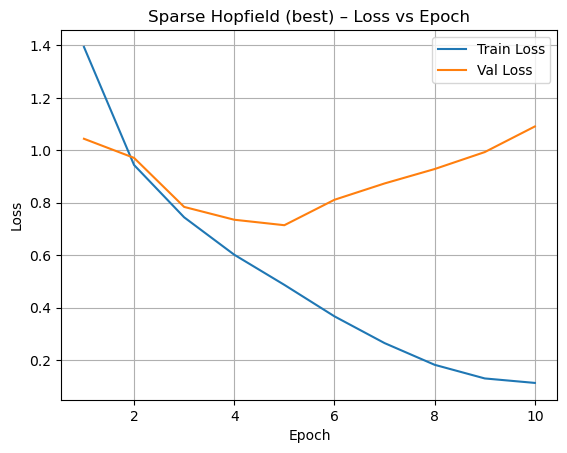

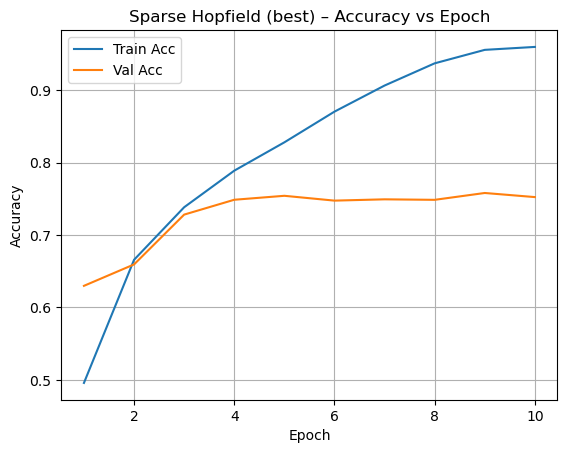

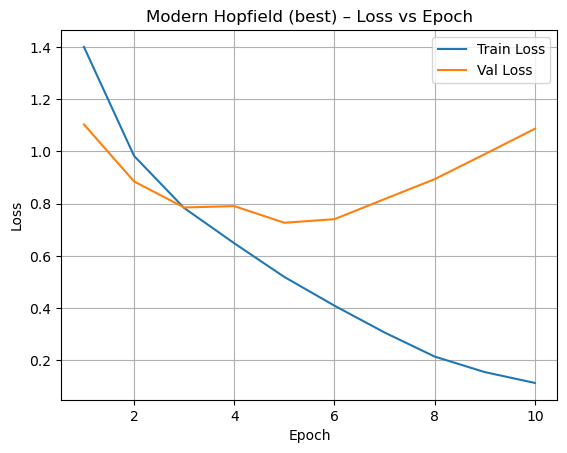

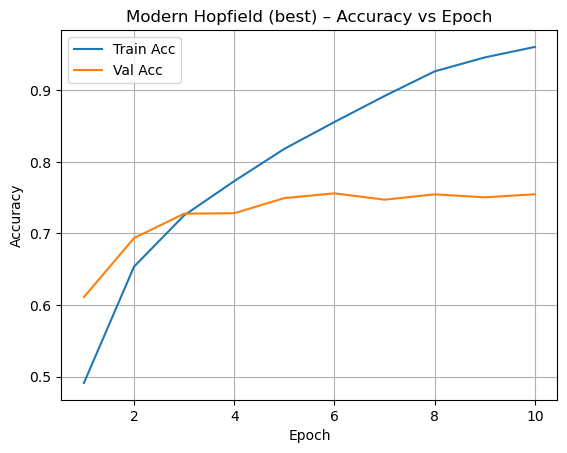

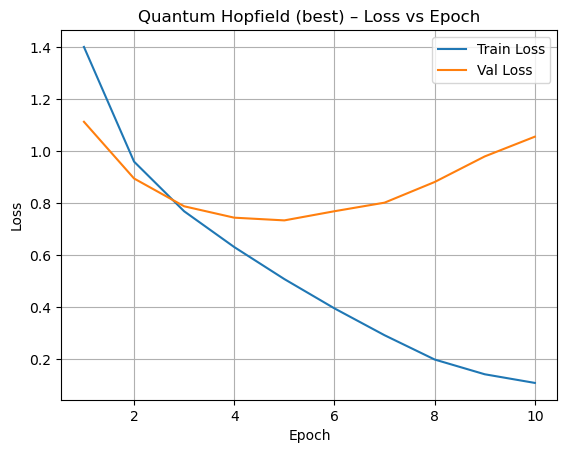

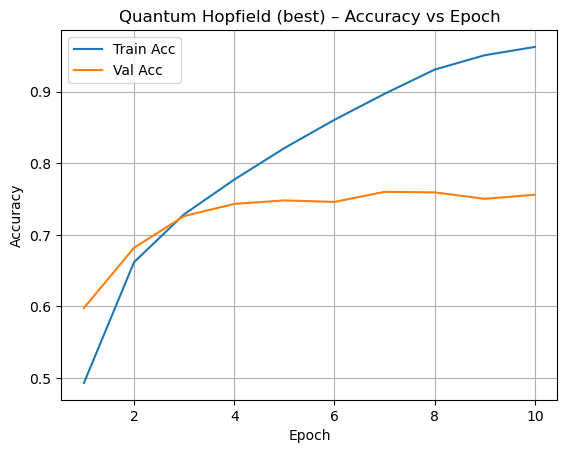

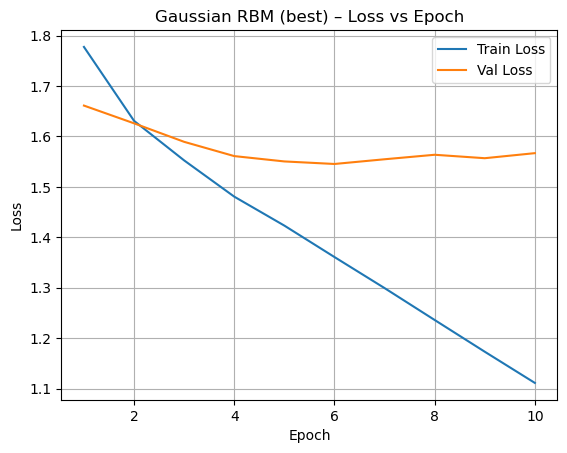

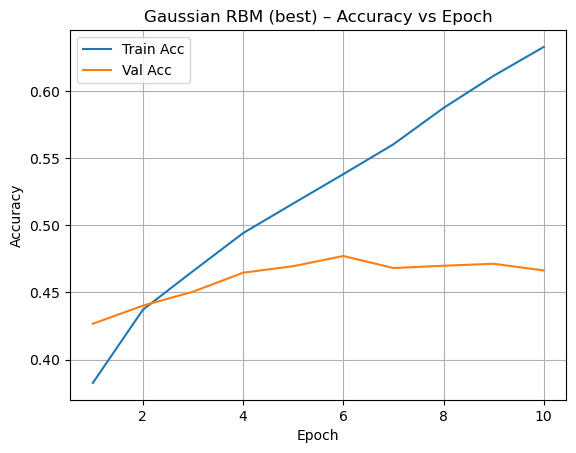

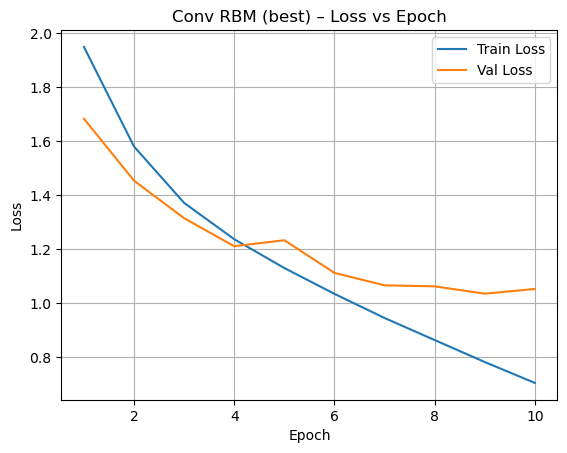

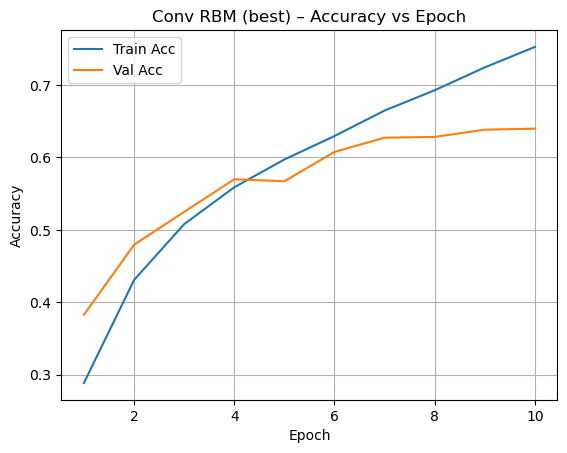

In [114]:
plot_learning_curves(hist_sparse,   title_prefix="Sparse Hopfield (best)")
plot_learning_curves(hist_modern,   title_prefix="Modern Hopfield (best)")
plot_learning_curves(hist_quantum,  title_prefix="Quantum Hopfield (best)")
plot_learning_curves(hist_gaussian, title_prefix="Gaussian RBM (best)")
plot_learning_curves(hist_conv,     title_prefix="Conv RBM (best)")


In [115]:
def get_final_metrics(history):
    idx = -1  
    return {
        "val_acc":      history["val_acc"][idx],
        "val_f1":       history["val_f1"][idx],
        "val_roc_auc":  history["val_roc_auc"][idx],
        "confusion_matrix": history["val_confusion_matrix"][idx],
    }


In [116]:
best_histories = [
    ("Sparse Hopfield (best)",   hist_sparse),
    ("Modern Hopfield (best)",   hist_modern),
    ("Quantum Hopfield (best)",  hist_quantum),
    ("Gaussian RBM (best)",      hist_gaussian),
    ("Conv RBM (best)",          hist_conv),
]

results = []

for name, hist in best_histories:
    m = get_final_metrics(hist)
    results.append((name, m))

    print(f"\n {name} – Validation Metrics (last epoch)")
    print(f"Val Accuracy : {m['val_acc']:.4f}")
    print(f"Val F1 score : {m['val_f1']:.4f}")
    print(f"Val ROC-AUC  : {m['val_roc_auc']:.4f}")
    print("Val Confusion Matrix:")
    print(m["confusion_matrix"])
    print("-" * 60)



 Sparse Hopfield (best) – Validation Metrics (last epoch)
Val Accuracy : 0.7523
Val F1 score : 0.7352
Val ROC-AUC  : 0.9670
Val Confusion Matrix:
[[813  12  52  23  18   8   5  15  55  41]
 [ 17 826   6   4   3   1  10   2  17 111]
 [ 42   3 705  68  51  34  43  26  13  16]
 [ 14   7  76 596  35 138  37  25   7  17]
 [ 21   4  94  81 678  25  21  62   8   5]
 [  6   0  71 200  46 586  14  40   3  10]
 [  4   4  53  72  39  15 771   9   4  11]
 [  6   5  43  68  46  31   8 799   4  10]
 [ 43  31  12   4   7   2   5   2 865  49]
 [ 20  47   9  23   2   2   4   8  12 884]]
------------------------------------------------------------

 Modern Hopfield (best) – Validation Metrics (last epoch)
Val Accuracy : 0.7547
Val F1 score : 0.7366
Val ROC-AUC  : 0.9675
Val Confusion Matrix:
[[844  27  27  13  11  21   3   7  51  38]
 [ 16 904   1   5   3   0   8   1   9  50]
 [ 72  10 606  61  84  65  56  27  13   7]
 [ 23  14  38 556  41 178  47  30   8  17]
 [ 29   3  60  57 711  36  27  70   4   2]